This notebook contains the first task in DELTA. Additionally, the notebook shows how to import the provided data.

### **1. Description of the first Task**

1)      What to submit?

We ask you to submit one zip archive including a Jupyter notebook and a csv file containing your predictions on the test set.

2)      Where to submit?

Submit the zip file via the corresponding Moodle module.

3)      Where to find the data?

The data sets for this task and the demo predictions file 'Demo_Predictions.csv' can be found on the main Moodle page under 'Task 1 Data'. The format of your predictions should be the same as the csv demo file. Also, your predictions should be in the original scale of the train and test datasets. The files 'DELTASS26_train_X.csv' and 'DELTASS26_test_X.csv' contain the predictors in the train and test set, respectviely. The file 'DELTASS26_train_y.csv' contains the target variable in the train set. You can use pandas to import your datasets in the following way: pd.read_csv(file_name,sep=',',header=0,index_col=0).


4)      What is expected?

You are provided with a tabular dataset containing 19 predictor features and 1 target variable. Your task is to build a neural network in keras/tensorflow to predict the continuous target variable. The data is separated into a train set of 1875 data samples, and a test set of 625 data samples.

The jupyter notebook should contain the following elements:

- Preprocessing of your datasets according to the requirements of neural networks. (different features have different descriptive statistics!)
- Implementation of 3 benchmark models: a linear model, a tree-based model and a neural network that has not been tuned. 
- Tuning of a neural network using a hyperparameter optimization library of your choice. The code for hyperparameter tuning should include regularization. 
- A well annotated plot showing the train vs. validation loss of the best performing neural network. 
- Additionally, you should provide an interpretation of why you believe the best performing architecture is suitable for your task in max. 3 sentences.
- A table showing all results (on a validation subset) from the tuned network and your benchmarks.
- Well documented code, which is divided into functions, classes, etc.


5)      How will your submissions be evaluated?

- Pass/fail: based on whether your notebook covers all required components mentioned above and whether your code runs without an error.
- Number of points: determined by the RMSE score of your predictions.

6)      Can I submit after the deadline?
We understand that unexpected circumstances sometimes lead to delayed submissions. While we will accept late submissions via e-mail, please keep in mind that there will be a deduction of 2 points per day for each day the submission is late.


### **2. Data Import**

So that you can import the data with the code cell below, you should put the data in the same folder of the notebook. Otherwise, you would have to adjust the file path.

In [1]:
import pandas as pd

#Predictor features on the train set:
train_X=pd.read_csv('DELTASS26_train_X.csv',sep=',',header=0,index_col=0)
#Target variable on the train set:
train_y=pd.read_csv('DELTASS26_train_y.csv',sep=',',header=0,index_col=0)
#Predictor features on the test set:
test_X=pd.read_csv('DELTASS26_test_X.csv',sep=',',header=0,index_col=0)
#Demo predictions file:
demo_predictions=pd.read_csv('Demo_Predictions.csv',sep=',',header=0,index_col=0)

In [2]:
train_X.head(5)

,0,1,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
2247,576.862876,118.941013,36.864442,-3844.453211,153.049833,1216.575188,1055.787408,111.237666,27.532591,2.121720,133.213740,499.184594,291.244141,122.809701,326.598858,-357.659748,0.733640,343.128068,7377.299492
816,-519.964665,152.487356,42.803957,8965.090492,175.423991,397.802231,2525.121784,106.036085,595.022787,-253.169013,-2.840755,138.972827,131.423179,134.734812,-3.910438,83.767176,557.159582,694.391959,-69002.946334
2153,-268.637257,201.446002,100.608799,7544.404518,133.975813,354.781676,1583.844900,109.957988,496.738147,-93.226084,15.624221,-69.819507,287.685650,273.224214,30.448455,194.724920,244.074657,366.901671,-41121.428175
1162,221.912111,132.390398,12.575263,-487.048745,136.090808,235.232175,744.472463,114.825842,-83.443809,110.480186,184.106522,1220.268567,230.930712,-9.886667,314.087609,-142.796921,2.428668,86.153047,7047.470827
480,949.533069,141.908066,106.633256,-5722.261554,72.590811,549.951299,686.233202,114.246343,16.245654,111.848648,174.065199,1050.920096,262.491938,-13.923644,196.254658,-41.436895,0.424431,53.277692,6376.903296


In [3]:
train_y.head(5)

,4
2247,909.619133
816,-114.186720
2153,-334.066552
1162,241.265155
480,-125.723772


### **3. Setup & Imports**

We import the libraries used throughout the notebook and fix random seeds for reproducibility:

- `scikit-learn` for the train/val split, K-fold CV, scaling, and the linear benchmark.
- `xgboost` for the tree-based benchmark.
- `tensorflow.keras` for the neural networks.
- `optuna` (with the TPE sampler — a guided/Bayesian search) for hyperparameter tuning.


In [4]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

import optuna
from optuna.samplers import TPESampler

# Reproducibility — fix all RNG seeds we touch
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Quieter logs while we tune / train many models.
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel("ERROR")

print("TensorFlow:", tf.__version__)
print("Optuna:", optuna.__version__)

TensorFlow: 2.21.0
Optuna: 4.8.0


/opt/anaconda3/envs/delta/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **4. Quick EDA**

Three checks before preprocessing: missing values, feature scales, and the target distribution.

In [5]:
# Shapes and missing-value check.
print(f"Shapes — train_X: {train_X.shape}, train_y: {train_y.shape}, test_X: {test_X.shape}")
print(
    f"Missing values — train_X: {train_X.isna().sum().sum()}, "
    f"train_y: {train_y.isna().sum().sum()}, "
    f"test_X: {test_X.isna().sum().sum()}"
)

Shapes — train_X: (1875, 19), train_y: (1875, 1), test_X: (625, 19)
Missing values — train_X: 0, train_y: 0, test_X: 0


In [6]:
train_X.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
0,130.16,809.85,-1674.07,1860.79
1,171.01,40.78,87.55,269.04
2,63.79,58.24,-57.12,130.82
3,-670.55,7982.16,-25702.97,35921.51
5,78.25,84.39,-100.68,199.39
6,117.46,709.96,-2162.21,2177.42
7,1150.51,805.45,-1557.25,5776.54
8,112.12,4.51,102.97,150.89
9,259.75,281.70,-177.68,738.05
10,-13.51,124.80,-323.11,182.09


In [7]:
train_y.describe().T

,count,mean,std,min,25%,50%,75%,max
4,1875.0,-67.058548,597.831616,-1243.548383,-497.747137,-171.66835,342.824017,1150.535752


**Conclusion: standardize.** Feature std spans 4.5 (feat. `8`) to ~35,000 (feat. `19`) — a ~7,800× ratio. Target std ≈ 600 is also on a wide scale. We apply `StandardScaler` to both `X` and `y`.

### **5. Preprocessing**

- `StandardScaler` on `X` and `y`, fit per fold to avoid leakage.
- Two splits: 5-fold CV for the results table and Optuna objective; a single 80/20 split for the best-model loss curve.
- RMSEs reported on the original `y` scale (`y` scaler inverted before scoring).

In [8]:
# Numpy arrays for cleaner indexing during cross-validation.
X_full = train_X.values.astype(np.float32)
y_full = train_y.values.ravel().astype(np.float32)
X_test_arr = test_X.values.astype(np.float32)

# 5-fold CV — used for the results table and as the Optuna objective.
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# Single 80/20 split — used only for the best-model loss curve.
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.2, random_state=SEED
)

print(f"X_full: {X_full.shape}   y_full: {y_full.shape}   X_test: {X_test_arr.shape}")
print(f"Plot-split sizes — train: {X_tr.shape[0]}, val: {X_val.shape[0]}")

X_full: (1875, 19)   y_full: (1875,)   X_test: (625, 19)
Plot-split sizes — train: 1500, val: 375


In [9]:
# Helpers reused across all benchmarks and Optuna trials.

def fit_scalers(X_train: np.ndarray, y_train: np.ndarray):
    """Fit a StandardScaler on the training portion only — no leakage from val/test."""
    x_scaler = StandardScaler().fit(X_train)
    y_scaler = StandardScaler().fit(y_train.reshape(-1, 1))
    return x_scaler, y_scaler


def transform_xy(x_scaler, y_scaler, X, y=None):
    """Apply already-fitted scalers; returns (X_scaled, y_scaled) or just X_scaled if y is None."""
    X_s = x_scaler.transform(X)
    if y is None:
        return X_s
    y_s = y_scaler.transform(y.reshape(-1, 1)).ravel()
    return X_s, y_s


def rmse_original_scale(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """RMSE in the original y units — y_pred must already be inverse-transformed."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

In [10]:
# Scale the fixed 80/20 split (CV folds will scale per-fold inside their own loops).
# Naming convention: `_s` suffix = scaled space (zero mean, unit variance).
# We keep the unscaled X_tr / X_val / y_tr / y_val around so predictions can be
# inverse-transformed and RMSE reported on the original y scale.
plot_x_scaler, plot_y_scaler = fit_scalers(X_tr, y_tr)
X_tr_s, y_tr_s = transform_xy(plot_x_scaler, plot_y_scaler, X_tr, y_tr)
X_val_s, y_val_s = transform_xy(plot_x_scaler, plot_y_scaler, X_val, y_val)

print(f"Sanity — X_tr_s mean: {X_tr_s.mean():.3f}, std: {X_tr_s.std():.3f}")
print(f"Sanity — y_tr_s mean: {y_tr_s.mean():.3f}, std: {y_tr_s.std():.3f}")

Sanity — X_tr_s mean: 0.000, std: 1.000
Sanity — y_tr_s mean: 0.000, std: 1.000


### **6. Benchmarks**

All four models are evaluated by 5-fold CV with per-fold scaling, RMSE reported on the original `y` scale. Linear and XGBoost share a CV helper because they are both sklearn-style; the NN benchmarks need their own loop (epochs, callbacks, target scaling).

In [11]:
def cv_score_sklearn(model_factory, X: np.ndarray, y: np.ndarray, kf: KFold) -> list[float]:
    """5-fold CV RMSE for any sklearn-style estimator. Scales X per fold; y stays raw."""
    # LinearRegression and XGBoost are y-scale invariant, so no y-scaling needed here.
    rmses = []
    for tr_idx, val_idx in kf.split(X):
        x_scaler, _ = fit_scalers(X[tr_idx], y[tr_idx])
        X_tr_s = x_scaler.transform(X[tr_idx])
        X_val_s = x_scaler.transform(X[val_idx])
        model = model_factory().fit(X_tr_s, y[tr_idx])
        y_pred = model.predict(X_val_s)
        rmses.append(rmse_original_scale(y[val_idx], y_pred))
    return rmses

#### 6.1 Linear baseline

In [12]:
linear_rmses = cv_score_sklearn(LinearRegression, X_full, y_full, kf)
print(f"Linear — fold RMSEs: {[round(r, 2) for r in linear_rmses]}")
print(f"         mean: {np.mean(linear_rmses):.2f}   std: {np.std(linear_rmses):.2f}")

Linear — fold RMSEs: [86.94, 88.31, 87.19, 90.83, 84.97]
         mean: 87.65   std: 1.92


#### 6.2 XGBoost baseline

Default `XGBRegressor` (n_estimators=100, max_depth=6, learning_rate=0.3) — no tuning, just a strong out-of-the-box gradient-boosted-tree benchmark.

In [13]:
def make_xgb():
    """Untuned XGBoost regressor with a fixed random state for reproducibility."""
    return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0)


xgb_rmses = cv_score_sklearn(make_xgb, X_full, y_full, kf)
print(f"XGBoost — fold RMSEs: {[round(r, 2) for r in xgb_rmses]}")
print(f"          mean: {np.mean(xgb_rmses):.2f}   std: {np.std(xgb_rmses):.2f}")

XGBoost — fold RMSEs: [53.34, 62.2, 59.97, 57.5, 53.53]
          mean: 57.31   std: 3.49


#### 6.3 Untuned NN baseline

A small `Sequential` model (Dense 64 → Dense 32 → Dense 1, ReLU, Adam, MSE) — no regularization, no tuning. The NN-specific CV helper below scales `y`, holds out 10 % of each fold's training portion as an internal validation split for `EarlyStopping`, and only uses the outer CV fold for the reported RMSE.

In [14]:
def cv_score_nn(
    build_fn,
    X: np.ndarray,
    y: np.ndarray,
    kf: KFold,
    epochs: int = 200,
    batch_size: int = 64,
    patience: int = 10,
    trial: optuna.Trial | None = None,
) -> list[float]:
    """5-fold CV RMSE for a Keras NN. Per fold: scale X+y on train portion, hold out 10% of train for EarlyStopping, evaluate on the outer fold. If `trial` is given, reports the running CV mean for Optuna pruning."""
    rmses = []
    for fold_i, (tr_idx, val_idx) in enumerate(kf.split(X)):
        x_scaler, y_scaler = fit_scalers(X[tr_idx], y[tr_idx])
        X_tr_s, y_tr_s = transform_xy(x_scaler, y_scaler, X[tr_idx], y[tr_idx])
        X_val_s = transform_xy(x_scaler, y_scaler, X[val_idx])

        model = build_fn(X.shape[1])
        es = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
        model.fit(
            X_tr_s, y_tr_s,
            validation_split=0.1,
            epochs=epochs, batch_size=batch_size,
            callbacks=[es], verbose=0,
        )

        y_pred_s = model.predict(X_val_s, verbose=0).ravel()
        y_pred = y_scaler.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()
        rmses.append(rmse_original_scale(y[val_idx], y_pred))

        if trial is not None:
            trial.report(float(np.mean(rmses)), step=fold_i)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return rmses

In [15]:
def build_untuned_nn(input_dim: int) -> keras.Model:
    """Untuned baseline: 2 hidden layers (ReLU + He init), Adam, MSE — no regularization."""
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(32, activation="relu", kernel_initializer="he_normal"),
        layers.Dense(1, activation="linear"),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model


untuned_rmses = cv_score_nn(build_untuned_nn, X_full, y_full, kf)
print(f"Untuned NN — fold RMSEs: {[round(r, 2) for r in untuned_rmses]}")
print(f"             mean: {np.mean(untuned_rmses):.2f}   std: {np.std(untuned_rmses):.2f}")

Untuned NN — fold RMSEs: [65.37, 69.83, 59.54, 66.95, 60.2]
             mean: 64.38   std: 3.95


### **7. Hyperparameter tuning with Optuna (TPE + MedianPruner)**

`Optuna`'s TPE sampler is a guided / Bayesian search: each trial is informed by previous trials' losses, so it concentrates samples in promising regions. Combined with a 5-fold CV objective (mean RMSE), this keeps configuration selection robust on a small (1875-row) dataset. `MedianPruner` cuts trials whose running CV mean is worse than the median of completed trials at the same fold, freeing budget for promising configurations.

**Search space.**

| Hyperparameter | Range | Notes |
|---|---|---|
| `n_layers` | 1–4 | Shallow → moderately deep |
| `units_l*` | 16–256, step 16 | Per-layer, allows tapered shapes |
| `activation` | relu / elu / tanh | Init: `he_normal` for relu/elu, `glorot_normal` for tanh |
| `use_batchnorm` | False / True | Pre-activation BatchNorm after each Dense |
| `dropout` | 0.0 – 0.5 | Per layer |
| `l2` | 1e-5 – 1e-2 (log) | `kernel_regularizer` |
| `lr` | 1e-4 – 1e-2 (log) | Adam |
| `batch_size` | 32 / 64 / 128 | |

Both forms of regularization (dropout + L2) are part of the search, satisfying the rubric requirement.

*L2 only: SGD-friendly and 19 dense features offer no sparsity for L1 to exploit. Sigmoid omitted: saturates and isn't zero-centered — tanh covers the saturating-activation case strictly better.*

In [16]:
def build_tuned_nn(input_dim: int, params: dict) -> keras.Model:
    """Parameterized NN builder used by Optuna. `params` follows the search-space schema."""
    init = "glorot_normal" if params["activation"] == "tanh" else "he_normal"
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for u in params["units"]:
        model.add(layers.Dense(
            u,
            kernel_initializer=init,
            kernel_regularizer=l2(params["l2"]),
        ))
        if params.get("use_batchnorm", False):
            model.add(layers.BatchNormalization())
        model.add(layers.Activation(params["activation"]))
        model.add(layers.Dropout(params["dropout"]))
    model.add(layers.Dense(1, activation="linear"))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=params["lr"]),
        loss="mse",
    )
    return model

In [17]:
def suggest_nn_params(trial: optuna.Trial) -> dict:
    """Sample one hyperparameter configuration from the search space."""
    n_layers = trial.suggest_int("n_layers", 1, 4)
    return {
        "n_layers": n_layers,
        "units": [trial.suggest_int(f"units_l{i}", 16, 256, step=16) for i in range(n_layers)],
        "activation": trial.suggest_categorical("activation", ["relu", "elu", "tanh"]),
        "use_batchnorm": trial.suggest_categorical("use_batchnorm", [False, True]),
        "dropout": trial.suggest_float("dropout", 0.0, 0.5),
        "l2": trial.suggest_float("l2", 1e-5, 1e-2, log=True),
        "lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [32, 64, 128]),
    }


def objective(trial: optuna.Trial) -> float:
    """Optuna objective: 5-fold CV mean RMSE (original y scale) for one hyperparameter set."""
    params = suggest_nn_params(trial)
    rmses = cv_score_nn(
        lambda d: build_tuned_nn(d, params),
        X_full, y_full, kf,
        epochs=400, batch_size=params["batch_size"], patience=10,
        trial=trial,
    )
    return float(np.mean(rmses))

In [18]:
# Long-running cell: 50 trials × 5-fold CV (with pruning) at 400 epochs ≈ 40-60 min depending on hardware.
N_TRIALS = 50

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=2),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

n_completed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)

print(f"\nTrials: {n_completed} completed, {n_pruned} pruned.")
print(f"Best CV RMSE: {study.best_value:.2f}")
print("Best params:")
for k, v in sorted(study.best_params.items()):
    print(f"  {k}: {v}")

Best trial: 36. Best value: 26.0354: 100%|██████████| 50/50 [57:03<00:00, 68.47s/it] 


Trials: 36 completed, 14 pruned.
Best CV RMSE: 26.04
Best params:
  activation: tanh
  batch_size: 64
  dropout: 0.0008487234482441354
  l2: 0.00024253870341184476
  lr: 0.00024278091955914308
  n_layers: 4
  units_l0: 160
  units_l1: 208
  units_l2: 224
  units_l3: 64
  use_batchnorm: False


### **8. Best model: refit & loss curve**

To produce the train vs. validation loss plot required by the rubric, we refit the best configuration **once** on the fixed 80/20 split (Section 5) and capture the Keras `history`. The 5-fold CV in Section 7 is what selected the config; this single training run is what the plot visualizes.

In [19]:
def best_params_from_study(study: optuna.Study) -> dict:
    """Reformat Optuna's flat best_params into the schema build_tuned_nn expects (units as list)."""
    bp = study.best_params
    return {
        "n_layers": bp["n_layers"],
        "units": [bp[f"units_l{i}"] for i in range(bp["n_layers"])],
        "activation": bp["activation"],
        "use_batchnorm": bp["use_batchnorm"],
        "dropout": bp["dropout"],
        "l2": bp["l2"],
        "lr": bp["lr"],
        "batch_size": bp["batch_size"],
    }


best_params = best_params_from_study(study)
print("Best NN config:", best_params)

Best NN config: {'n_layers': 4, 'units': [160, 208, 224, 64], 'activation': 'tanh', 'use_batchnorm': False, 'dropout': 0.0008487234482441354, 'l2': 0.00024253870341184476, 'lr': 0.00024278091955914308, 'batch_size': 64}


In [20]:
# Refit on the (already-scaled) 80/20 plot split, capturing history.
# Validation comes from the held-out 375 rows — gives a clean train-vs-val curve.
MAX_EPOCHS = 800
best_model = build_tuned_nn(X_tr_s.shape[1], best_params)
es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

history = best_model.fit(
    X_tr_s, y_tr_s,
    validation_data=(X_val_s, y_val_s),
    epochs=MAX_EPOCHS,
    batch_size=best_params["batch_size"],
    callbacks=[es],
    verbose=0,
)

# Val RMSE on the original y scale.
y_val_pred_s = best_model.predict(X_val_s, verbose=0).ravel()
y_val_pred = plot_y_scaler.inverse_transform(y_val_pred_s.reshape(-1, 1)).ravel()
tuned_val_rmse_plot = rmse_original_scale(y_val, y_val_pred)

trained_epochs = len(history.history["loss"])
es_triggered = trained_epochs < MAX_EPOCHS
print(f"Trained for {trained_epochs} epochs "
      f"({'EarlyStopping triggered' if es_triggered else 'reached MAX_EPOCHS without EarlyStopping'}).")
print(f"Plot-split val RMSE (original y scale): {tuned_val_rmse_plot:.2f}")

Trained for 429 epochs (EarlyStopping triggered).
Plot-split val RMSE (original y scale): 24.34


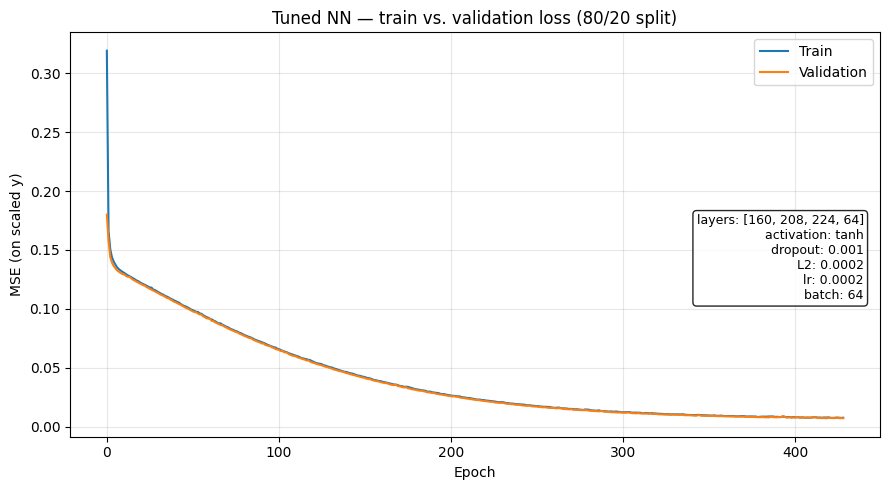

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(history.history["loss"], label="Train")
ax.plot(history.history["val_loss"], label="Validation")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (on scaled y)")
ax.set_title("Tuned NN — train vs. validation loss (80/20 split)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Annotate the plot with the chosen configuration.
ax.text(
    0.98, 0.55,
    f"layers: {best_params['units']}\n"
    f"activation: {best_params['activation']}\n"
    f"dropout: {best_params['dropout']:.3f}\n"
    f"L2: {best_params['l2']:.4f}\n"
    f"lr: {best_params['lr']:.4f}\n"
    f"batch: {best_params['batch_size']}",
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="right",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
)

plt.tight_layout()
plt.show()

### **9. Results table**

5-fold CV mean and standard deviation for each model, all on the same per-fold validation slices and reported on the original `y` scale. Optuna only persists trial means, so we re-run 5-fold CV with the best config below to obtain fold-level RMSEs.

In [22]:
# Re-run 5-fold CV with the tuned config so we have per-fold RMSEs (study only stored means).
# Uses MAX_EPOCHS + EarlyStopping, matching the plot-split refit budget.
tuned_rmses = cv_score_nn(
    lambda d: build_tuned_nn(d, best_params),
    X_full, y_full, kf,
    epochs=MAX_EPOCHS,
    batch_size=best_params["batch_size"],
    patience=10,
)
print(f"Tuned NN — fold RMSEs: {[round(r, 2) for r in tuned_rmses]}")
print(f"           mean: {np.mean(tuned_rmses):.2f}   std: {np.std(tuned_rmses):.2f}")

Tuned NN — fold RMSEs: [26.19, 25.76, 25.5, 26.85, 24.31]
           mean: 25.72   std: 0.84


In [23]:
results = pd.DataFrame(
    {
        "Model": ["Linear", "XGBoost (defaults)", "Untuned NN", "Tuned NN (Optuna)"],
        "CV mean RMSE": [
            np.mean(linear_rmses),
            np.mean(xgb_rmses),
            np.mean(untuned_rmses),
            np.mean(tuned_rmses),
        ],
        "CV std": [
            np.std(linear_rmses),
            np.std(xgb_rmses),
            np.std(untuned_rmses),
            np.std(tuned_rmses),
        ],
    }
).round(2)
results

,Model,CV mean RMSE,CV std
0,Linear,87.65,1.92
1,XGBoost (defaults),57.31,3.49
2,Untuned NN,64.38,3.95
3,Tuned NN (Optuna),25.72,0.84


### **10. Why this architecture is suitable for the task** *(max 3 sentences)*

The four tapered hidden layers (160 → 208 → 224 → 64) with `tanh` activations have enough capacity to model nonlinear interactions among the 19 mixed-scale predictors, and `tanh` is well matched to standardized inputs that stay inside its responsive range and to a bounded, standardized target. Explicit regularization is minimal (L2 ≈ 2 × 10⁻⁴, dropout ≈ 10⁻³) because `EarlyStopping` already restores the best-validation weights and so implicitly regularizes — stronger penalties would underfit a model that needs ~430 epochs at a low learning rate (lr ≈ 2 × 10⁻⁴) to converge. The CV standard deviation drops from 3.95 (untuned NN) to 0.84 here, which is consistent with the chosen configuration finding a stable basin in the loss surface rather than an overfit one.

### **11. Test predictions**

We refit the tuned configuration on **all 1875 training rows** (no further hold-out for the loss curve — we already have it). A 10 % internal `validation_split` is used for `EarlyStopping` only, so all training labels still inform the fit. Predictions are inverse-transformed to the original `y` scale and saved in the same format as `Demo_Predictions.csv`.

In [24]:
# Fit scalers on the full training set (no leakage — test_X never sees y).
final_x_scaler, final_y_scaler = fit_scalers(X_full, y_full)
X_full_s, y_full_s = transform_xy(final_x_scaler, final_y_scaler, X_full, y_full)
X_test_s = transform_xy(final_x_scaler, final_y_scaler, X_test_arr)

# Refit the tuned NN on all training data; internal 10 % val split for EarlyStopping only.
final_model = build_tuned_nn(X_full.shape[1], best_params)
final_es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
final_model.fit(
    X_full_s, y_full_s,
    validation_split=0.1,
    epochs=MAX_EPOCHS,
    batch_size=best_params["batch_size"],
    callbacks=[final_es],
    verbose=0,
)

# Predict on the test set and invert y-scaling.
y_test_pred_s = final_model.predict(X_test_s, verbose=0).ravel()
y_test_pred = final_y_scaler.inverse_transform(y_test_pred_s.reshape(-1, 1)).ravel()

# Save in the Demo_Predictions.csv format: numeric index 0..624, "Predictions" column.
predictions_df = pd.DataFrame({"Predictions": y_test_pred})
predictions_df.to_csv("Predictions.csv")
print(f"Saved {len(predictions_df)} predictions to Predictions.csv")
predictions_df.head()

Saved 625 predictions to Predictions.csv


,Predictions
0,-868.333923
1,885.767151
2,552.854248
3,917.830933
4,-311.812805
